# Transformaciones a Tiempo-Frecuencia


In [1]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.736484,-0.009636,1.178945,1.235709,0.510713,-1.831197,1.153277,1.375999,1.166158,0.367772,0.372550,0.070037,0.896983,0.846142,0,0.000000
1,0.630255,-0.164882,1.365325,1.327963,-0.033855,-1.815302,1.168870,1.147867,0.407848,-0.319549,0.214932,0.017004,0.770335,0.618404,0,0.007812
2,0.674703,-0.096572,1.501320,1.568564,-0.199946,-1.967427,1.170797,0.911751,0.530619,-0.380182,0.201532,0.153103,0.725777,0.695611,0,0.015625
3,0.739805,0.086415,1.510323,1.595198,0.083062,-2.007020,1.156651,0.795702,0.812917,0.222368,0.335384,0.417372,0.767920,0.928266,0,0.023438
4,0.649864,0.063729,1.296289,1.437884,0.349025,-1.824252,1.117905,0.560304,0.453218,0.559581,0.444195,0.471846,0.788656,0.970052,0,0.031250


## Transformada de fourier de corto plazo


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [4]:
def apply_stft(series, fs = FS, window_sec = 2, overlap_pct = 0.75):
    n_per_seg = int(window_sec * fs)
    n_overlap = int(n_per_seg * overlap_pct)

    f, t, Zxx = stft(series, fs=fs, window='hann', nperseg=n_per_seg, noverlap=n_overlap)
    psd = np.abs(Zxx)
    
    return f, t, psd

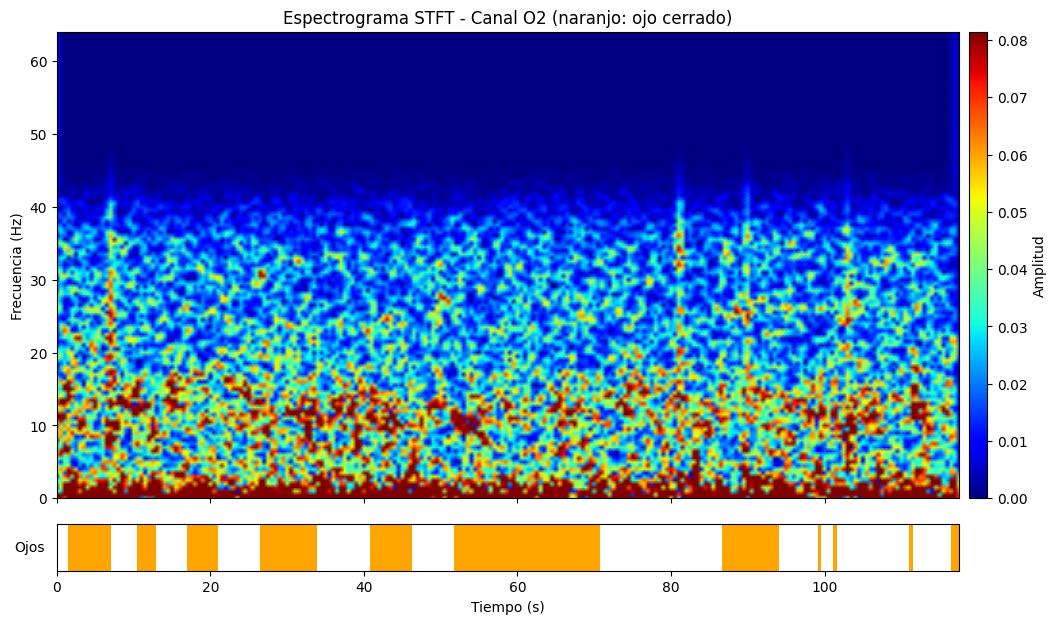

In [5]:
# --- Computar STFT para los 14 canales ---
stft_arrays = {}
stft_freqs, stft_times = None, None

for ch in CHANNELS:
    f, t, psd = apply_stft(df[ch])
    stft_arrays[ch] = psd
    if stft_freqs is None:
        stft_freqs = f
        stft_times = t

labels_stft = np.array([
    df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL]
    for ti in stft_times
])

# --- Visualización O2 ---
target = 'O2'
psd_viz = stft_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(stft_times, stft_freqs, psd_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(psd_viz, 95))
ax1.set_title(f'Espectrograma STFT - Canal {target} (naranjo: ojo cerrado)')
ax1.set_ylabel('Frecuencia (Hz)')
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im, cax=cax, label='Amplitud')
states_matrix = labels_stft.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[stft_times.min(), stft_times.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(stft_times.min(), stft_times.max())
ax2.set_xlim(stft_times.min(), stft_times.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
cax2.axis('off')
plt.show()

## Transformada de Wavelet


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

In [7]:
def apply_cwt(series, fs=FS, freq_min=4, freq_max=40, n_freqs=80, wavelet='cmor1.5-1.0'):
    """
    Aplica la Transformada Wavelet Continua (CWT) a una señal EEG.

    Parámetros
    ----------
    series    : array-like  - Señal de entrada (1D).
    fs        : int         - Frecuencia de muestreo en Hz.
    freq_min  : float       - Frecuencia mínima de análisis en Hz.
    freq_max  : float       - Frecuencia máxima de análisis en Hz.
    n_freqs   : int         - Número de escalas (resolución frecuencial).
    wavelet   : str         - Wavelet madre. Se usa Morlet compleja (cmor) por
                              su localización conjunta tiempo-frecuencia.

    Retorna
    -------
    freqs     : ndarray     - Frecuencias correspondientes a cada escala (Hz).
    t         : ndarray     - Vector de tiempo (s).
    power     : ndarray     - Densidad de potencia espectral |CWT|² (freqs × tiempo).
    """
    # Calcular escalas a partir del rango de frecuencias deseado
    # pywt.scale2frequency convierte escala → frecuencia: f = f_c / (escala * dt)
    dt = 1.0 / fs
    central_freq = pywt.central_frequency(wavelet)
    scales = central_freq / (np.linspace(freq_min, freq_max, n_freqs) * dt)
    scales = scales[::-1]  # ordenar de menor a mayor escala (mayor a menor frecuencia)

    signal = np.array(series, dtype=np.float64)
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=dt)

    # Densidad de potencia: módulo al cuadrado de los coeficientes complejos
    power = np.abs(coeffs) ** 2
    t = np.arange(len(signal)) * dt

    return freqs, t, power

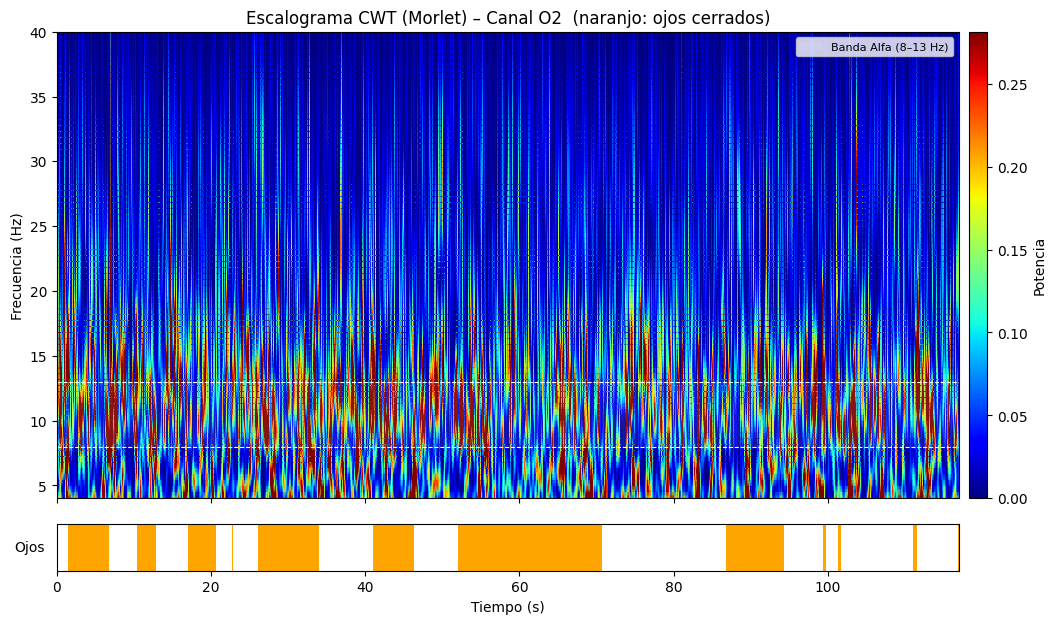

In [8]:
# --- Computar CWT para los 14 canales ---
cwt_arrays = {}
cwt_freqs_arr, cwt_times_arr = None, None

for ch in CHANNELS:
    freqs_cwt, t_cwt, power = apply_cwt(df[ch], fs=FS)
    cwt_arrays[ch] = power
    if cwt_freqs_arr is None:
        cwt_freqs_arr = freqs_cwt
        cwt_times_arr = t_cwt

labels_cwt = np.array([
    df.iloc[(df['time_sec'] - ti).abs().idxmin()][TARGET_COL]
    for ti in cwt_times_arr
])

# --- Visualización O2 ---
target = 'O2'
power_viz = cwt_arrays[target]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [10, 1]})
plt.subplots_adjust(hspace=0.1)
im = ax1.pcolormesh(cwt_times_arr, cwt_freqs_arr, power_viz, shading='gouraud', cmap='jet',
                    vmin=0, vmax=np.percentile(power_viz, 95))
ax1.axhspan(8, 13, color='white', alpha=0.08, lw=0, label='Banda Alfa (8–13 Hz)')
ax1.axhline(8,  color='white', linestyle='--', linewidth=0.8)
ax1.axhline(13, color='white', linestyle='--', linewidth=0.8)
ax1.set_title(f'Escalograma CWT (Morlet) – Canal {target}  (naranjo: ojos cerrados)')
ax1.set_ylabel('Frecuencia (Hz)')
ax1.legend(loc='upper right', fontsize=8)
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im, cax=cax, label='Potencia')
states_matrix = labels_cwt.reshape(1, -1)
cmap_eye = mcolors.ListedColormap(['white', 'orange'])
ax2.imshow(states_matrix, aspect='auto', cmap=cmap_eye,
           extent=[cwt_times_arr.min(), cwt_times_arr.max(), 0, 1], interpolation='nearest')
ax2.set_yticks([])
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('Ojos', rotation=0, labelpad=20, va='center')
ax1.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
ax2.set_xlim(cwt_times_arr.min(), cwt_times_arr.max())
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='2%', pad=0.1)
cax2.axis('off')
plt.show()

In [9]:
save_dir = Path('./data/tf_representations')
save_dir.mkdir(parents=True, exist_ok=True)

# --- Guardar ---
np.savez(save_dir / 'stft.npz', **stft_arrays, freqs=stft_freqs, times=stft_times, labels=labels_stft)
np.savez(save_dir / 'cwt.npz',  **cwt_arrays,  freqs=cwt_freqs_arr, times=cwt_times_arr, labels=labels_cwt)

# --- Verificar ---
print("Archivos guardados en:", save_dir.resolve())
print()
for name in ['stft.npz', 'cwt.npz']:
    data = np.load(save_dir / name)
    canal_shape = data[CHANNELS[0]].shape
    print(f"{name}:")
    print(f"  Claves    : {list(data.keys())}")
    print(f"  Shape O2  : {data['O2'].shape}")
    print(f"  Shape freqs: {data['freqs'].shape}  |  times: {data['times'].shape}  |  labels: {data['labels'].shape}")
    print(f"  Clases    : {np.unique(data['labels'])}")
    print(f"  Canales OK: {all(ch in data for ch in CHANNELS)}")
    print()

Archivos guardados en: /home/madmti/Work/UNIVERSIDAD/benjaauf-PROY-INF405/data/tf_representations

stft.npz:
  Claves    : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2  : (129, 236)
  Shape freqs: (129,)  |  times: (236,)  |  labels: (236,)
  Clases    : [0. 1.]
  Canales OK: True

cwt.npz:
  Claves    : ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'freqs', 'times', 'labels']
  Shape O2  : (80, 14980)
  Shape freqs: (80,)  |  times: (14980,)  |  labels: (14980,)
  Clases    : [0. 1.]
  Canales OK: True

